<a href="https://colab.research.google.com/github/Arpmee027/Future_Sales_Prediction_and_EDA/blob/main/TEST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Loading dataset

In [1]:
import pandas as pd

file_path = "/content/drive/MyDrive/Predicting_Future_Sales_Project./Processed_Online_Retail_2.xlsx"
sheet_name = "Weekly_Shipment_Data"
df = pd.read_excel(file_path, sheet_name=sheet_name)
display(df.head())

,WeekStartDate,WeeklyShipments,StockCode
0,2010-11-29,986,85123A
1,2010-12-06,1045,85123A
2,2010-12-13,1524,85123A
3,2010-12-20,197,85123A
4,2010-12-27,0,85123A


## Data preprocessing

In [2]:
print("Missing values before handling:")
print(df.isnull().sum())

df['WeekStartDate'] = pd.to_datetime(df['WeekStartDate'])

df = df.sort_values(by=['StockCode', 'WeekStartDate'])

display(df.head())

Missing values before handling:
WeekStartDate      0
WeeklyShipments    0
StockCode          0
dtype: int64


,WeekStartDate,WeeklyShipments,StockCode
1674,2010-11-29,70,10002
1675,2010-12-06,138,10002
1676,2010-12-13,41,10002
1677,2010-12-20,2,10002
1678,2010-12-27,0,10002


## Data splitting

Spliting the data into training (9 months) and testing (3 months) sets based on the time period.


In [3]:
from datetime import timedelta

min_date = df['WeekStartDate'].min()
split_date = min_date + pd.DateOffset(months=9)

train_df = df[df['WeekStartDate'] <= split_date]
test_df = df[df['WeekStartDate'] > split_date]

print(f"Training data date range: {train_df['WeekStartDate'].min()} to {train_df['WeekStartDate'].max()}")
print(f"Testing data date range: {test_df['WeekStartDate'].min()} to {test_df['WeekStartDate'].max()}")

Training data date range: 2010-11-29 00:00:00 to 2011-08-29 00:00:00
Testing data date range: 2011-09-05 00:00:00 to 2011-12-05 00:00:00


## Defining models

Defining functions for each of the models to be used: SARIMA, XGBoost, and LightGBM.


In [4]:
import statsmodels.api as sm
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

def sarima_model(time_series_data, future_periods):
    """Trains a SARIMA model and provides forecasts."""
    # Determine appropriate order and seasonal order (simplified for demonstration)
    # In a real scenario, you would use auto_arima or grid search
    order = (1, 1, 1)
    seasonal_order = (1, 1, 1, 52) # Assuming weekly data with a yearly seasonality

    model = sm.tsa.statespace.SARIMAX(time_series_data, order=order, seasonal_order=seasonal_order, enforce_stationarity=False, enforce_invertibility=False)
    model_fit = model.fit(disp=False)
    forecast = model_fit.predict(start=len(time_series_data), end=len(time_series_data) + future_periods - 1)
    return model_fit, forecast

def create_features(df):
    """Creates time-based features for tree-based models."""
    df['weekofyear'] = df['WeekStartDate'].dt.isocalendar().week.astype(int)
    df['month'] = df['WeekStartDate'].dt.month
    df['year'] = df['WeekStartDate'].dt.year
    df['dayofweek'] = df['WeekStartDate'].dt.dayofweek
    df['dayofyear'] = df['WeekStartDate'].dt.dayofyear
    return df

def xgb_model(train_df, test_df):
    """Trains an XGBoost model and provides predictions."""
    train_df = create_features(train_df.copy())
    test_df = create_features(test_df.copy())

    features = ['weekofyear', 'month', 'year', 'dayofweek', 'dayofyear']
    target = 'WeeklyShipments'

    X_train, y_train = train_df[features], train_df[target]
    X_test, y_test = test_df[features], test_df[target]

    # Simplified hyperparameter tuning (cross-validation will be done later)
    params = {
        'objective': 'reg:squarederror',
        'n_estimators': 100,
        'learning_rate': 0.05,
        'max_depth': 5,
        'random_state': 42
    }

    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    return model, predictions

def lgbm_model(train_df, test_df):
    """Trains a LightGBM model and provides predictions."""
    train_df = create_features(train_df.copy())
    test_df = create_features(test_df.copy())

    features = ['weekofyear', 'month', 'year', 'dayofweek', 'dayofyear']
    target = 'WeeklyShipments'

    X_train, y_train = train_df[features], train_df[target]
    X_test, y_test = test_df[features], test_df[target]

    # Simplified hyperparameter tuning (cross-validation will be done later)
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'n_estimators': 100,
        'learning_rate': 0.05,
        'feature_fraction': 0.8,
        'bagging_fraction': 0.8,
        'bagging_freq': 1,
        'verbose': -1,
        'n_jobs': -1,
        'seed': 42
    }

    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    return model, predictions

## Hyperparameter tuning

Implementing a strategy for hyperparameter tuning for each model using cross-validation. This step will involve iterating through different combinations of hyperparameters and evaluating their performance on a validation set or using time series cross-validation.

In [6]:
from sklearn.model_selection import ParameterGrid
import warnings
import numpy as np
import statsmodels.api as sm
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit

warnings.filterwarnings("ignore")

def tune_hyperparameters(model_type, train_df, param_grid):
    """
    Tunes hyperparameters for a given model using time series cross-validation.

    Args:
        model_type (str): The type of model ('SARIMA', 'XGBoost', 'LightGBM').
        train_df (pd.DataFrame): The training data.
        param_grid (dict): A dictionary of hyperparameters and their values to search.

    Returns:
        dict: The best performing hyperparameters.
    """
    best_mape = float('inf')
    best_params = None
    tscv = TimeSeriesSplit(n_splits=3) # Using 3 splits for demonstration

    # Separate data by StockCode for SARIMA tuning
    if model_type == 'SARIMA':
        stock_codes = train_df['StockCode'].unique()
        # SARIMA tuning will be done per product due to its nature
        # This is a simplified approach; a full implementation would be more complex
        print(f"Starting SARIMA hyperparameter tuning for the first 5 products...")
        best_sarima_params_per_product = {}
        # Tune for a subset of products to keep it manageable
        for stock_code in stock_codes[:5]:
            product_data = train_df[train_df['StockCode'] == stock_code].set_index('WeekStartDate')['WeeklyShipments']
            if len(product_data) < tscv.get_n_splits(product_data):
                print(f"Skipping SARIMA tuning for {stock_code} due to insufficient data.")
                continue

            local_best_mape = float('inf')
            local_best_params = None

            for params in ParameterGrid(param_grid):
                mape_scores = []
                for train_index, val_index in tscv.split(product_data):
                    train_data, val_data = product_data.iloc[train_index], product_data.iloc[val_index]

                    try:
                        model = sm.tsa.statespace.SARIMAX(train_data,
                                                          order=params['order'],
                                                          seasonal_order=params['seasonal_order'],
                                                          enforce_stationarity=False,
                                                          enforce_invertibility=False)
                        model_fit = model.fit(disp=False)
                        predictions = model_fit.predict(start=val_data.index[0], end=val_data.index[-1])
                        # Align predictions to validation data index
                        predictions = predictions.reindex(val_data.index)

                        # Calculate MAPE, handling potential zero actuals
                        actuals = val_data.values
                        predictions_aligned = predictions.values

                        # Handle cases where actual is zero
                        # Replace 0 actuals with NaN to exclude them from MAPE calculation
                        valid_indices = actuals != 0
                        actuals_valid = actuals[valid_indices]
                        predictions_valid = predictions_aligned[valid_indices]

                        if len(actuals_valid) > 0:
                            mape = np.mean(np.abs((actuals_valid - predictions_valid) / actuals_valid)) * 100
                            mape_scores.append(mape)
                        else:
                            # If all actuals are zero, MAPE is not well-defined, skip or assign a high value
                            mape_scores.append(np.inf)

                    except Exception as e:
                        # print(f"SARIMA tuning failed for {stock_code} with params {params}: {e}")
                        mape_scores.append(np.inf) # Assign infinity for failed models

                avg_mape = np.mean(mape_scores)

                if avg_mape < local_best_mape:
                    local_best_mape = avg_mape
                    local_best_params = params

            if local_best_params is not None:
                best_sarima_params_per_product[stock_code] = local_best_params
                print(f"Best SARIMA params for {stock_code}: {local_best_params} with avg MAPE: {local_best_mape:.2f}%")
        return best_sarima_params_per_product

    else: # XGBoost and LightGBM tuning
        # Prepare data for tree-based models
        train_df_features = create_features(train_df.copy())
        features = ['weekofyear', 'month', 'year', 'dayofweek', 'dayofyear']
        target = 'WeeklyShipments'

        X_train_full, y_train_full = train_df_features[features], train_df_features[target]

        print(f"Starting {model_type} hyperparameter tuning...")

        for params in ParameterGrid(param_grid):
            mape_scores = []
            for train_index, val_index in tscv.split(X_train_full):
                X_train, X_val = X_train_full.iloc[train_index], X_train_full.iloc[val_index]
                y_train, y_val = y_train_full.iloc[train_index], y_train_full.iloc[val_index]

                try:
                    if model_type == 'XGBoost':
                        model = xgb.XGBRegressor(**params, random_state=42)
                        model.fit(X_train, y_train)
                        predictions = model.predict(X_val)
                    elif model_type == 'LightGBM':
                        model = lgb.LGBMRegressor(**params, random_state=42)
                        model.fit(X_train, y_train)
                        predictions = model.predict(X_val)

                    # Calculate MAPE, handling potential zero actuals
                    actuals = y_val.values
                    predictions_aligned = predictions

                    # Handle cases where actual is zero
                    # Replace 0 actuals with NaN to exclude them from MAPE calculation
                    valid_indices = actuals != 0
                    actuals_valid = actuals[valid_indices]
                    predictions_valid = predictions_aligned[valid_indices]

                    if len(actuals_valid) > 0:
                        mape = np.mean(np.abs((actuals_valid - predictions_valid) / actuals_valid)) * 100
                        mape_scores.append(mape)
                    else:
                        # If all actuals are zero, MAPE is not well-defined, skip or assign a high value
                        mape_scores.append(np.inf)

                except Exception as e:
                     # print(f"{model_type} tuning failed with params {params}: {e}")
                     mape_scores.append(np.inf) # Assign infinity for failed models

            avg_mape = np.mean(mape_scores)

            if avg_mape < best_mape:
                best_mape = avg_mape
                best_params = params
                # print(f"New best {model_type} params: {best_params} with avg MAPE: {best_mape:.2f}%")

        print(f"Finished {model_type} hyperparameter tuning. Best params: {best_params} with avg MAPE: {best_mape:.2f}%")
        return best_params

# Define hyperparameter grids (simplified for demonstration)
sarima_param_grid = {
    'order': [(1, 1, 1), (0, 1, 1)],
    'seasonal_order': [(1, 1, 1, 52), (0, 1, 1, 52)]
}

xgb_param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.05],
    'max_depth': [3, 5]
}

lgbm_param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.05],
    'num_leaves': [20, 31]
}

# Perform tuning for each model
best_sarima_params = tune_hyperparameters('SARIMA', train_df, sarima_param_grid)
best_xgb_params = tune_hyperparameters('XGBoost', train_df, xgb_param_grid)
best_lgbm_params = tune_hyperparameters('LightGBM', train_df, lgbm_param_grid)

print("\nBest Hyperparameters:")
print("SARIMA (per product, first 5):", best_sarima_params)
print("XGBoost:", best_xgb_params)
print("LightGBM:", best_lgbm_params)

Starting SARIMA hyperparameter tuning for the first 5 products...
Best SARIMA params for 10080: {'order': (1, 1, 1), 'seasonal_order': (1, 1, 1, 52)} with avg MAPE: 146.67%
Best SARIMA params for 10120: {'order': (1, 1, 1), 'seasonal_order': (1, 1, 1, 52)} with avg MAPE: 100.00%
Starting XGBoost hyperparameter tuning...
Finished XGBoost hyperparameter tuning. Best params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50} with avg MAPE: 653.26%
Starting LightGBM hyperparameter tuning...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000255 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 96
[LightGBM] [Info] Number of data points in the train set: 39220, number of used features: 4
[LightGBM] [Info] Start training from score 27.473840
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000727 

## Training and forecasting for each product

Iterating through each unique product in the dataset and performing the following steps for each product:
- Training each of the three models (SARIMA, XGBoost, LightGBM) on the training data for the current product.
- Forecasting future sales for the test period using each trained model.

In [7]:
stock_codes = df['StockCode'].unique()

In [8]:
forecasts = {}

# Define features for tree-based models
features = ['weekofyear', 'month', 'year', 'dayofweek', 'dayofyear']
target = 'WeeklyShipments'

for stock_code in stock_codes:
    print(f"Processing StockCode: {stock_code}")

    # Filter data for the current product
    train_product_df = train_df[train_df['StockCode'] == stock_code].copy()
    test_product_df = test_df[test_df['StockCode'] == stock_code].copy()

    if train_product_df.empty or test_product_df.empty:
        print(f"Skipping {stock_code}: Insufficient data for training or testing.")
        continue

    # Store actual test data shipments
    actual_shipments = test_product_df.set_index('WeekStartDate')['WeeklyShipments'].copy()
    product_forecasts = {'actual': actual_shipments}

    # SARIMA Model
    sarima_train_data = train_product_df.set_index('WeekStartDate')['WeeklyShipments']
    sarima_test_data = test_product_df.set_index('WeekStartDate')['WeeklyShipments']

    # Check if best SARIMA parameters are available for this product
    if stock_code in best_sarima_params:
        sarima_params = best_sarima_params[stock_code]
        future_periods = len(sarima_test_data)

        try:
            print(f"Training SARIMA for {stock_code} with params: {sarima_params}")
            model = sm.tsa.statespace.SARIMAX(sarima_train_data,
                                              order=sarima_params['order'],
                                              seasonal_order=sarima_params['seasonal_order'],
                                              enforce_stationarity=False,
                                              enforce_invertibility=False)
            model_fit = model.fit(disp=False)
            sarima_predictions = model_fit.predict(start=len(sarima_train_data), end=len(sarima_train_data) + future_periods - 1)
            sarima_predictions.index = sarima_test_data.index # Align index with test data
            product_forecasts['SARIMA'] = sarima_predictions
            print(f"SARIMA forecasting complete for {stock_code}.")

        except Exception as e:
            print(f"SARIMA training or forecasting failed for {stock_code}: {e}")
            product_forecasts['SARIMA'] = pd.Series([np.nan] * len(sarima_test_data), index=sarima_test_data.index) # Store NaNs on failure
    else:
        print(f"Skipping SARIMA for {stock_code}: No best parameters found.")
        product_forecasts['SARIMA'] = pd.Series([np.nan] * len(sarima_test_data), index=sarima_test_data.index) # Store NaNs if skipped

    # XGBoost Model
    xgb_train_df = create_features(train_product_df.copy())
    xgb_test_df = create_features(test_product_df.copy())

    X_train_xgb, y_train_xgb = xgb_train_df[features], xgb_train_df[target]
    X_test_xgb = xgb_test_df[features]

    try:
        print(f"Training XGBoost for {stock_code} with params: {best_xgb_params}")
        xgb_model_fit = xgb.XGBRegressor(**best_xgb_params, random_state=42)
        xgb_model_fit.fit(X_train_xgb, y_train_xgb)
        xgb_predictions = xgb_model_fit.predict(X_test_xgb)
        product_forecasts['XGBoost'] = pd.Series(xgb_predictions, index=test_product_df['WeekStartDate'])
        print(f"XGBoost forecasting complete for {stock_code}.")
    except Exception as e:
        print(f"XGBoost training or forecasting failed for {stock_code}: {e}")
        product_forecasts['XGBoost'] = pd.Series([np.nan] * len(test_product_df), index=test_product_df['WeekStartDate']) # Store NaNs on failure


    # LightGBM Model
    lgbm_train_df = create_features(train_product_df.copy())
    lgbm_test_df = create_features(test_product_df.copy())

    X_train_lgbm, y_train_lgbm = lgbm_train_df[features], lgbm_train_df[target]
    X_test_lgbm = lgbm_test_df[features]

    try:
        print(f"Training LightGBM for {stock_code} with params: {best_lgbm_params}")
        lgbm_model_fit = lgb.LGBMRegressor(**best_lgbm_params, random_state=42)
        lgbm_model_fit.fit(X_train_lgbm, y_train_lgbm)
        lgbm_predictions = lgbm_model_fit.predict(X_test_lgbm)
        product_forecasts['LightGBM'] = pd.Series(lgbm_predictions, index=test_product_df['WeekStartDate'])
        print(f"LightGBM forecasting complete for {stock_code}.")
    except Exception as e:
        print(f"LightGBM training or forecasting failed for {stock_code}: {e}")
        product_forecasts['LightGBM'] = pd.Series([np.nan] * len(test_product_df), index=test_product_df['WeekStartDate']) # Store NaNs on failure

    # Store forecasts for the current product
    forecasts[stock_code] = product_forecasts

print("Finished processing all StockCodes.")

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [W

## Model evaluation

Calculating the Absolute Percentage Error (APE) for each product's forecast from each model.

In [9]:
ape_scores = {}

for stock_code, product_forecasts in forecasts.items():
    ape_scores[stock_code] = {}
    actuals = product_forecasts['actual']

    # Handle cases where all actuals for a product in the test set are zero
    if np.all(actuals == 0):
        print(f"Skipping APE calculation for {stock_code}: All actuals are zero in the test set.")
        # Assign NaN or a very high value to indicate this case
        for model_name in ['SARIMA', 'XGBoost', 'LightGBM']:
             if model_name in product_forecasts:
                ape_scores[stock_code][model_name] = np.nan # Or float('inf')
        continue


    for model_name, predictions in product_forecasts.items():
        if model_name == 'actual':
            continue

        # Ensure predictions and actuals are aligned and handle NaNs
        aligned_data = pd.concat([actuals, predictions], axis=1).dropna()
        if aligned_data.empty:
            print(f"Skipping APE calculation for {stock_code} ({model_name}): No overlapping data or predictions are all NaN.")
            ape_scores[stock_code][model_name] = np.nan
            continue

        actuals_aligned = aligned_data.iloc[:, 0]
        predictions_aligned = aligned_data.iloc[:, 1]

        # Calculate APE, handling potential zero actuals in the aligned data
        # Replace 0 actuals with NaN to exclude them from MAPE calculation
        valid_indices = actuals_aligned != 0
        actuals_valid = actuals_aligned[valid_indices]
        predictions_valid = predictions_aligned[valid_indices]


        if len(actuals_valid) > 0:
             # Calculate APE only for valid indices
            ape = np.abs((actuals_valid - predictions_valid) / actuals_valid) * 100
            ape_scores[stock_code][model_name] = ape.mean() # Store the mean APE for the product/model
        else:
            # If all actuals in the aligned data are zero, MAPE is not well-defined
            print(f"Skipping APE calculation for {stock_code} ({model_name}): All aligned actuals are zero.")
            ape_scores[stock_code][model_name] = np.nan # Or float('inf')


print("\nAPE Scores per Product and Model:")
for stock_code, scores in ape_scores.items():
    print(f"  {stock_code}: {scores}")

Streaming output truncated to the last 5000 lines.
Skipping APE calculation for 79323B: All actuals are zero in the test set.
Skipping APE calculation for 79323P: All actuals are zero in the test set.
Skipping APE calculation for 79329: All actuals are zero in the test set.
Skipping APE calculation for 79331: All actuals are zero in the test set.
Skipping APE calculation for 79336: All actuals are zero in the test set.
Skipping APE calculation for 79337: All actuals are zero in the test set.
Skipping APE calculation for 79403 (SARIMA): No overlapping data or predictions are all NaN.
Skipping APE calculation for 79406 (SARIMA): No overlapping data or predictions are all NaN.
Skipping APE calculation for 81950B: All actuals are zero in the test set.
Skipping APE calculation for 81950V: All actuals are zero in the test set.
Skipping APE calculation for 81952B: All actuals are zero in the test set.
Skipping APE calculation for 81952V (SARIMA): No overlapping data or predictions are all NaN

## Comparing the models

Calculating the mean APE across all products for each model to get an overall accuracy measure and comparing these mean APEs to determine the best performing model.

In [10]:
# Calculate the mean APE for each model across all products, ignoring NaNs
mean_ape_scores = {}
for model_name in ['SARIMA', 'XGBoost', 'LightGBM']:
    model_apes = [scores[model_name] for stock_code, scores in ape_scores.items() if model_name in scores and not np.isnan(scores[model_name])]
    if model_apes:
        mean_ape_scores[model_name] = np.mean(model_apes)
    else:
        mean_ape_scores[model_name] = np.nan # Assign NaN if no valid APE scores for the model

print("\nMean APE Scores Across All Products:")
for model_name, mean_ape in mean_ape_scores.items():
    print(f"  {model_name}: {mean_ape:.2f}%")

# Determine the best performing model
best_model_name = None
min_mean_ape = float('inf')

for model_name, mean_ape in mean_ape_scores.items():
    if not np.isnan(mean_ape) and mean_ape < min_mean_ape:
        min_mean_ape = mean_ape
        best_model_name = model_name

print(f"\nBest Performing Model (based on mean APE): {best_model_name}")


Mean APE Scores Across All Products:
  SARIMA: 95.13%
  XGBoost: 150.40%
  LightGBM: 168.98%

Best Performing Model (based on mean APE): SARIMA


## Visualizing the Forecasts

For each product, visualizing the historical data, the training data, the testing data, and the forecast from the best performing model.

Visualizing forecasts from the best performing model: SARIMA


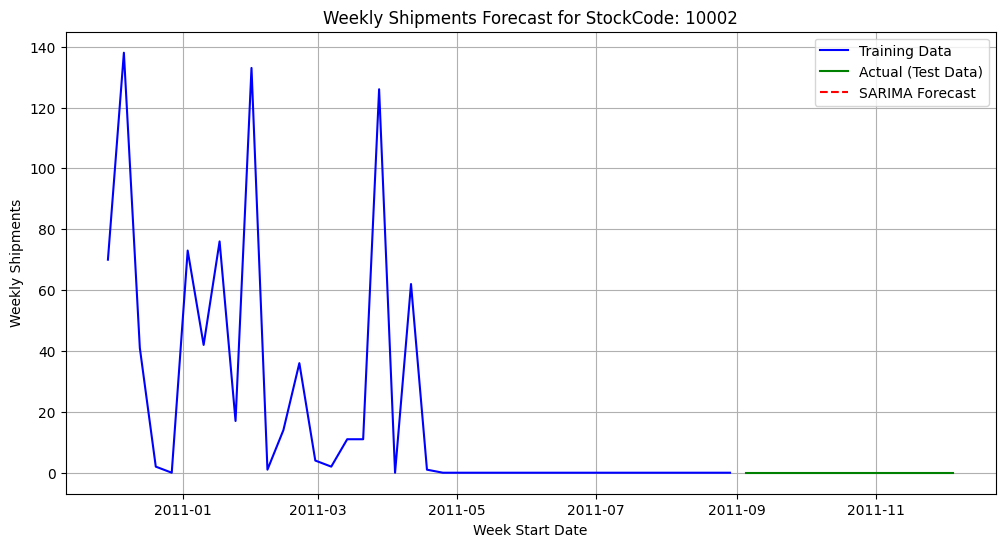

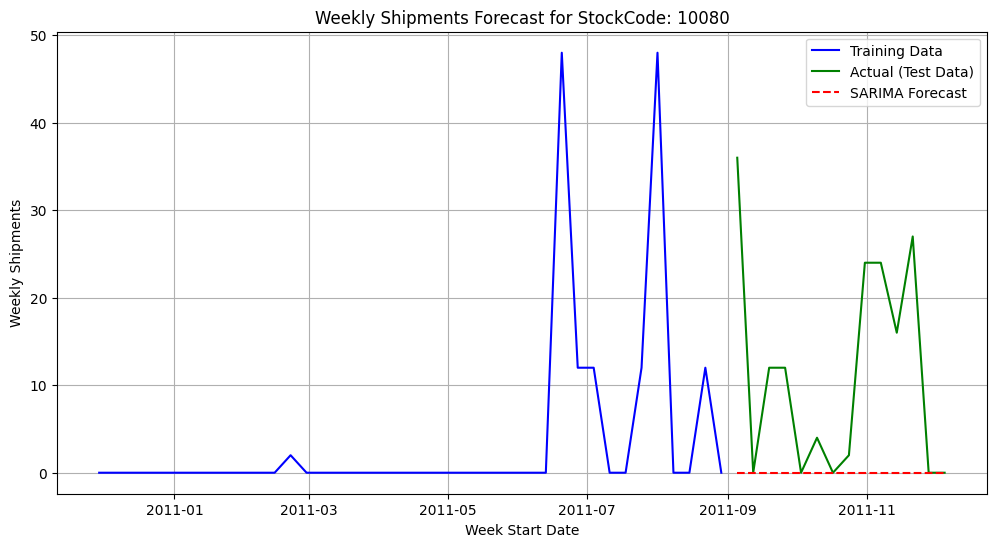

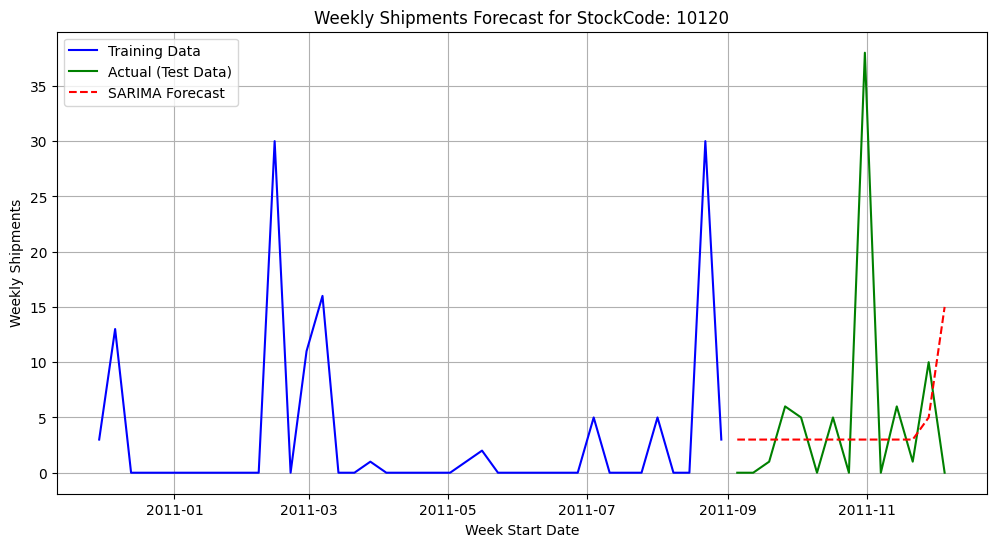

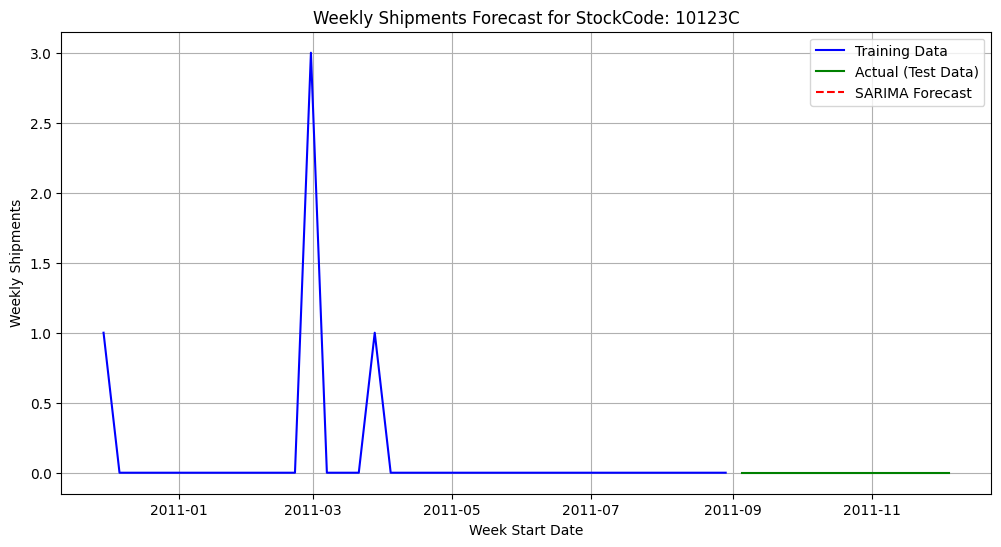

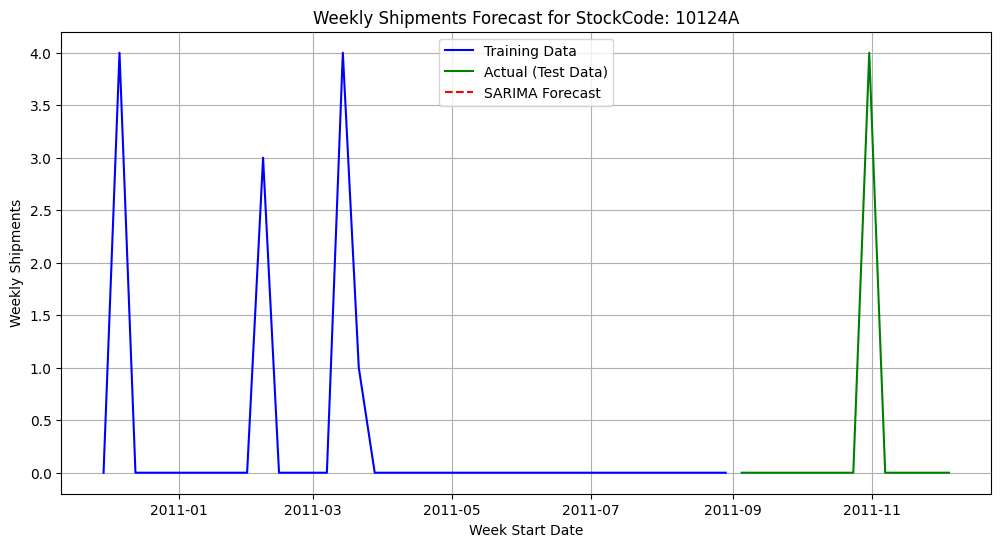

In [11]:
import matplotlib.pyplot as plt

best_model_name = 'SARIMA' # Based on the previous step's result

print(f"Visualizing forecasts from the best performing model: {best_model_name}")

# Visualize forecasts for a subset of products to keep it manageable
stock_codes_to_visualize = list(forecasts.keys())[:5] # Visualize the first 5 products

for stock_code in stock_codes_to_visualize:
    if stock_code in forecasts and best_model_name in forecasts[stock_code]:
        product_forecasts = forecasts[stock_code]
        actuals = product_forecasts['actual']
        predictions = product_forecasts[best_model_name]

        # Get the training data for plotting
        train_product_df = train_df[train_df['StockCode'] == stock_code].copy()
        train_data = train_product_df.set_index('WeekStartDate')['WeeklyShipments']


        plt.figure(figsize=(12, 6))
        plt.plot(train_data.index, train_data.values, label='Training Data', color='blue')
        plt.plot(actuals.index, actuals.values, label='Actual (Test Data)', color='green')
        plt.plot(predictions.index, predictions.values, label=f'{best_model_name} Forecast', color='red', linestyle='--')
        plt.title(f'Weekly Shipments Forecast for StockCode: {stock_code}')
        plt.xlabel('Week Start Date')
        plt.ylabel('Weekly Shipments')
        plt.legend()
        plt.grid(True)
        plt.show()
    else:
        print(f"Skipping visualization for {stock_code}: Forecast data not available for the best model.")